In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [93]:
activity = pd.read_csv("data/atusact_2024.dat")
respondent = pd.read_csv("data/atusresp_2024.dat")
roster = pd.read_csv("data/atusrost_2024.dat")
who = pd.read_csv("data/atuswho_2024.dat")
cps = pd.read_csv("data/atuscps_2024.dat")

In [52]:
#filter activity 0301-- 0302-- 0303--
childcare = activity[activity["TRCODE"].astype(str).str.startswith(("301", "302", "303"))]
work = activity[activity["TRCODE"].astype(str).str.startswith("5")]

In [32]:
roster["family_size"] = roster.groupby("TUCASEID")["TUCASEID"].transform("count")
only_respondent = roster[(roster["TERRP"] == 18) | (roster["TERRP"] == 19)]
resp_all = pd.merge(only_respondent, respondent, on = "TUCASEID")

In [33]:
resp_all

,TUCASEID,TULINENO_x,TEAGE,TERRP,TESEX,TXAGE,TXRRP,TXSEX,family_size,TULINENO_y,...,TXSPUHRS,TXTCC,TXTCCTOT,TXTCOC,TXTHH,TXTNOHH,TXTO,TXTOHH,TXTONHH,TRLVMODR
0,20240101240005,1,29,18,2,0,0,0,4,1,...,-1,0,0,0,0,-1,0,0,-1,1
1,20240101240020,1,77,19,2,0,0,0,1,1,...,-1,-1,0,0,-1,-1,-1,-1,-1,-1
2,20240101240098,1,19,18,1,0,0,0,6,1,...,-1,0,0,0,0,0,-1,-1,-1,1
3,20240101240107,1,23,19,2,0,0,0,2,1,...,0,-1,0,0,-1,-1,-1,-1,-1,1
4,20240101240123,1,22,18,2,0,0,0,2,1,...,-1,0,0,0,0,-1,0,0,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7664,20241212242238,1,25,19,2,0,0,0,2,1,...,0,-1,0,0,-1,-1,-1,-1,-1,1
7665,20241212242273,1,30,18,2,0,0,0,2,1,...,0,-1,0,0,-1,-1,-1,-1,-1,1
7666,20241212242280,1,77,19,2,0,0,0,1,1,...,-1,-1,0,0,-1,-1,-1,-1,-1,-1
7667,20241212242281,1,37,18,1,0,0,0,4,1,...,-1,0,0,0,0,-1,0,0,-1,1


In [34]:
parents = pd.merge(childcare, resp_all, on = "TUCASEID")

In [35]:
parents

,TUCASEID,TUACTIVITY_N,TEWHERE,TRTCCTOT_LN,TRTCC_LN,TRTCOC_LN,TRTEC_LN,TRTHH_LN,TRTNOHH_LN,TRTOHH_LN,...,TXSPUHRS,TXTCC,TXTCCTOT,TXTCOC,TXTHH,TXTNOHH,TXTO,TXTOHH,TXTONHH,TRLVMODR
0,20240101240005,2,1,0,0,0,-1,0,-1,0,...,-1,0,0,0,0,-1,0,0,-1,1
1,20240101240005,3,1,0,0,0,-1,0,-1,0,...,-1,0,0,0,0,-1,0,0,-1,1
2,20240101240005,4,1,0,0,0,-1,0,-1,0,...,-1,0,0,0,0,-1,0,0,-1,1
3,20240101240005,5,1,0,0,0,-1,0,-1,0,...,-1,0,0,0,0,-1,0,0,-1,1
4,20240101240005,7,11,0,0,0,-1,0,-1,0,...,-1,0,0,0,0,-1,0,0,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5014,20241212242281,9,3,0,0,0,-1,0,-1,0,...,-1,0,0,0,0,-1,0,0,-1,1
5015,20241212242281,10,3,0,0,0,-1,0,-1,0,...,-1,0,0,0,0,-1,0,0,-1,1
5016,20241212242281,11,3,0,0,0,-1,0,-1,0,...,-1,0,0,0,0,-1,0,0,-1,1
5017,20241212242281,12,3,0,0,0,-1,0,-1,0,...,-1,0,0,0,0,-1,0,0,-1,1


In [97]:
parents["oneperson"] = parents["family_size"] == 2
parents["oneperson"].value_counts()

oneperson
False    4779
True      240
Name: count, dtype: int64

,TUCASEID,TUACTIVITY_N,TEWHERE,TRTCCTOT_LN,TRTCC_LN,TRTCOC_LN,TRTEC_LN,TRTHH_LN,TRTNOHH_LN,TRTOHH_LN,...,TXTCC,TXTCCTOT,TXTCOC,TXTHH,TXTNOHH,TXTO,TXTOHH,TXTONHH,TRLVMODR,oneperson
0,20240101240005,2,1,0,0,0,-1,0,-1,0,...,0,0,0,0,-1,0,0,-1,1,False
1,20240101240005,3,1,0,0,0,-1,0,-1,0,...,0,0,0,0,-1,0,0,-1,1,False
2,20240101240005,4,1,0,0,0,-1,0,-1,0,...,0,0,0,0,-1,0,0,-1,1,False
3,20240101240005,5,1,0,0,0,-1,0,-1,0,...,0,0,0,0,-1,0,0,-1,1,False
4,20240101240005,7,11,0,0,0,-1,0,-1,0,...,0,0,0,0,-1,0,0,-1,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5014,20241212242281,9,3,0,0,0,-1,0,-1,0,...,0,0,0,0,-1,0,0,-1,1,False
5015,20241212242281,10,3,0,0,0,-1,0,-1,0,...,0,0,0,0,-1,0,0,-1,1,False
5016,20241212242281,11,3,0,0,0,-1,0,-1,0,...,0,0,0,0,-1,0,0,-1,1,False
5017,20241212242281,12,3,0,0,0,-1,0,-1,0,...,0,0,0,0,-1,0,0,-1,1,False


In [99]:
parents["total_length"] = parents.groupby("TUCASEID")["TUACTDUR"].transform("sum")

In [100]:
parents["total_length"]

0       203
1       203
2       203
3       203
4       203
       ... 
5014    180
5015    180
5016    180
5017    180
5018    180
Name: total_length, Length: 5019, dtype: int64

In [101]:
parents

,TUCASEID,TUACTIVITY_N,TEWHERE,TRTCCTOT_LN,TRTCC_LN,TRTCOC_LN,TRTEC_LN,TRTHH_LN,TRTNOHH_LN,TRTOHH_LN,...,TXTCCTOT,TXTCOC,TXTHH,TXTNOHH,TXTO,TXTOHH,TXTONHH,TRLVMODR,oneperson,total_length
0,20240101240005,2,1,0,0,0,-1,0,-1,0,...,0,0,0,-1,0,0,-1,1,False,203
1,20240101240005,3,1,0,0,0,-1,0,-1,0,...,0,0,0,-1,0,0,-1,1,False,203
2,20240101240005,4,1,0,0,0,-1,0,-1,0,...,0,0,0,-1,0,0,-1,1,False,203
3,20240101240005,5,1,0,0,0,-1,0,-1,0,...,0,0,0,-1,0,0,-1,1,False,203
4,20240101240005,7,11,0,0,0,-1,0,-1,0,...,0,0,0,-1,0,0,-1,1,False,203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5014,20241212242281,9,3,0,0,0,-1,0,-1,0,...,0,0,0,-1,0,0,-1,1,False,180
5015,20241212242281,10,3,0,0,0,-1,0,-1,0,...,0,0,0,-1,0,0,-1,1,False,180
5016,20241212242281,11,3,0,0,0,-1,0,-1,0,...,0,0,0,-1,0,0,-1,1,False,180
5017,20241212242281,12,3,0,0,0,-1,0,-1,0,...,0,0,0,-1,0,0,-1,1,False,180


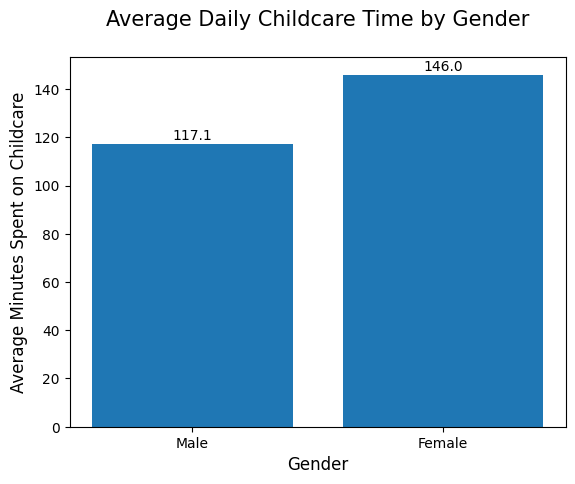

In [102]:
# total childcare time per respondent
childcare_totals = (
    parents.groupby(["TUCASEID", "TESEX"])["TUACTDUR24"]
    .sum()
    .reset_index()
)
gender_avg = (
    childcare_totals.groupby("TESEX")["TUACTDUR24"]
    .mean()
    .reset_index()
)
gender_avg["Gender"] = gender_avg["TESEX"].map({1: "Male", 2: "Female"})

plot = plt.bar(gender_avg["Gender"], gender_avg["TUACTDUR24"])

plt.xlabel("Gender", fontsize = 12)
plt.ylabel("Average Minutes Spent on Childcare", fontsize = 12)
plt.title("Average Daily Childcare Time by Gender\n", fontsize=15)
plt.bar_label(plot, fmt="%.1f", padding=1)

plt.show()

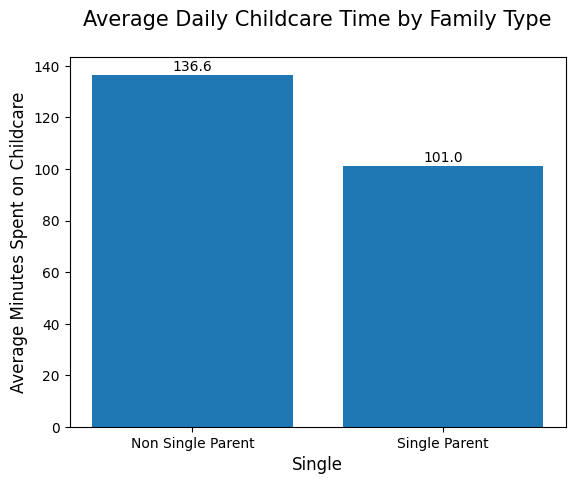

In [109]:
single_totals = (
    parents.groupby(["TUCASEID", "oneperson"])["TUACTDUR24"]
    .sum()
    .reset_index()
)
single_avg = (
    single_totals.groupby("oneperson")["TUACTDUR24"]
    .mean()
    .reset_index()
)
single_avg["Single"] = single_avg["oneperson"].map({False: "Non Single Parent", True: "Single Parent"})

plot = plt.bar(single_avg["Single"], single_avg["TUACTDUR24"])

plt.xlabel("Single", fontsize = 12)
plt.ylabel("Average Minutes Spent on Childcare", fontsize = 12)
plt.title("Average Daily Childcare Time by Family Type\n", fontsize=15)
plt.bar_label(plot, fmt="%.1f", padding=1)

plt.show()

In [74]:
work["work_time"] = work.groupby("TUCASEID")["TUACTDUR"].transform("sum")
working_parents = pd.merge(parents,work, on = "TUCASEID")

/var/folders/s8/lp9jvnbj11b4d2m7lz4n_brh0000gn/T/ipykernel_85538/2822907738.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  work["work_time"] = work.groupby("TUCASEID")["TUACTDUR"].transform("sum")


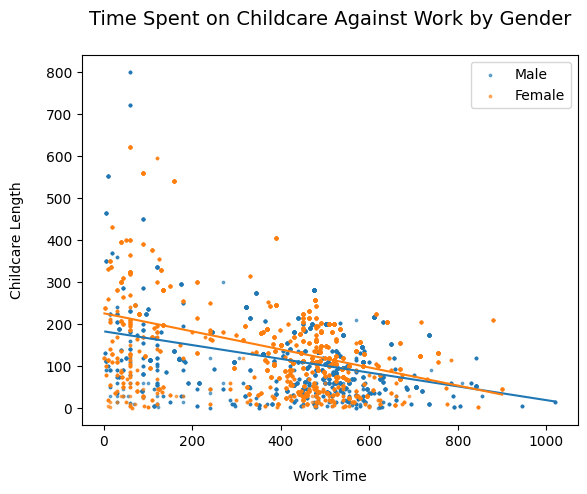

In [92]:
male = working_parents[working_parents["Gender"] == "Male"]
female = working_parents[working_parents["Gender"] == "Female"]

plt.scatter(male["work_time"], male["total_length"], label="Male", alpha = 0.6, s = 3)
plt.scatter(female["work_time"], female["total_length"], label="Female", alpha = 0.6, s = 3)

m_male, b_male = np.polyfit(male["work_time"], male["total_length"], 1)
m_female, b_female = np.polyfit(female["work_time"], female["total_length"], 1)

# Sort x for clean lines
x_male = np.sort(male["work_time"])
x_female = np.sort(female["work_time"])

plt.plot(x_male, m_male*x_male + b_male)
plt.plot(x_female, m_female*x_female + b_female)


plt.xlabel("\nWork Time")
plt.ylabel("Childcare Length\n")
plt.title("Time Spent on Childcare Against Work by Gender\n", fontsize = 14)
plt.legend()
plt.show()
